In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import rasterio
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

In [4]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Training hyperparameters (easy to modify)
BATCH_SIZE = 8
NUM_WORKERS = 2
LR = 1e-4
NUM_EPOCHS = 100
EARLY_STOPPING_PATIENCE = None  # set to None to disable
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
DATASET_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")

IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)

Images: /content/drive/MyDrive/Cellula/WaterSegmentation/data/images
Labels: /content/drive/MyDrive/Cellula/WaterSegmentation/data/labels


In [6]:
NUM_CHANNELS = 12

NORM_CHANNELS = [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]

EXCLUDE_FROM_NORM = [7, 10]  # QA Band, WorldCover

assert len(NORM_CHANNELS) + len(EXCLUDE_FROM_NORM) == NUM_CHANNELS

print("Channels to normalize:", NORM_CHANNELS)
print("Channels excluded from normalization:", EXCLUDE_FROM_NORM)

Channels to normalize: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]
Channels excluded from normalization: [7, 10]


In [7]:
pairs = []

for image_path in sorted(IMAGES_DIR.glob("*.tif")):

    label_path = LABELS_DIR / f"{image_path.stem}.png"

    if label_path.exists():
        pairs.append((image_path, label_path))

print("Total image-mask pairs:", len(pairs))

Total image-mask pairs: 306


In [8]:
def has_water(label_path):
    with rasterio.open(label_path) as src:
        mask = src.read(1)
    return int(np.any(mask == 1))

strat_labels = np.array([has_water(lbl) for _, lbl in pairs])
print("Images with water:", int(np.sum(strat_labels == 1)))
print("Images without water:", int(np.sum(strat_labels == 0)))

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Images with water: 261
Images without water: 45


In [9]:
total_water = 0
total_bg = 0
for _, lbl in pairs:
    with rasterio.open(lbl) as src:
        m = src.read(1)
    total_water += int((m == 1).sum())
    total_bg += int((m == 0).sum())

total_px = total_water + total_bg
print(f"\nWater pixels: {total_water} ({total_water/total_px*100:.2f}%)")
print(f"Background:   {total_bg} ({total_bg/total_px*100:.2f}%)")
print(f"Suggested pos_weight: {total_bg / max(total_water, 1):.4f}")


Water pixels: 1302272 (25.98%)
Background:   3711232 (74.02%)
Suggested pos_weight: 2.8498


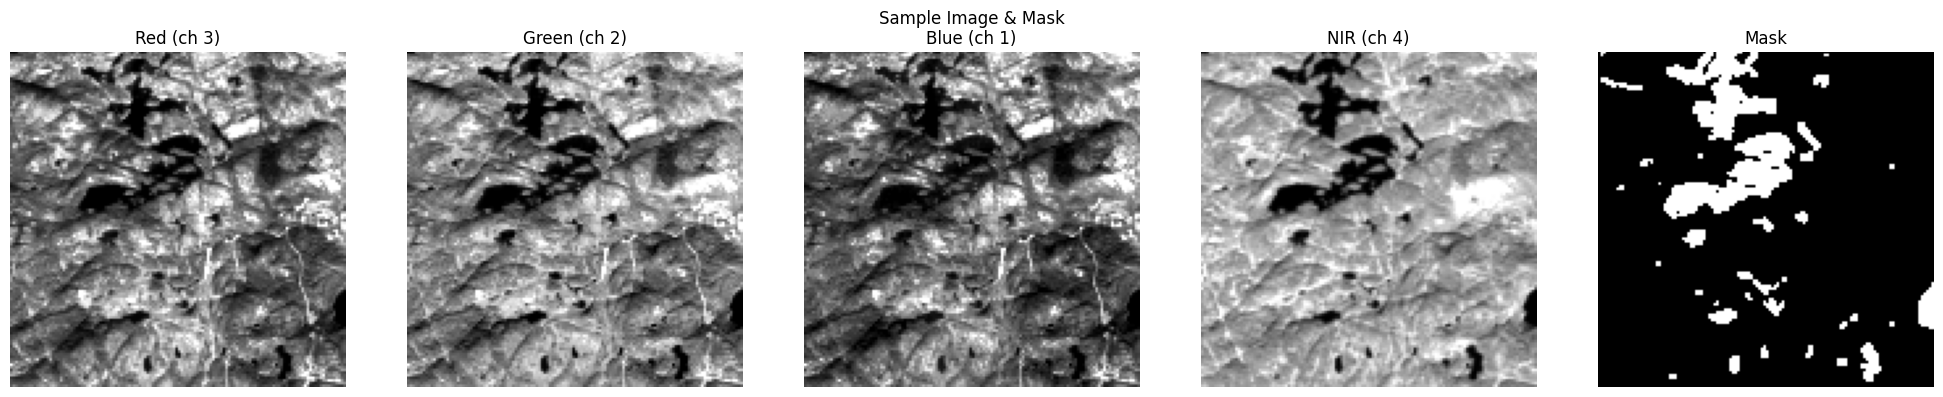

In [10]:
# Visualize a sample image (RGB + NIR) and its mask
img_path, msk_path = pairs[0]
with rasterio.open(img_path) as src:
    img_raw = src.read().astype(np.float32)
with rasterio.open(msk_path) as src:
    msk_raw = src.read(1)

show_channels = [3, 2, 1, 4]
names = ["Red (ch 3)", "Green (ch 2)", "Blue (ch 1)", "NIR (ch 4)"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, ch, name in zip(axes[:4], show_channels, names):
    band = img_raw[ch]
    vmin, vmax = np.percentile(band, (2, 98))
    ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(name)
    ax.axis("off")
axes[4].imshow(msk_raw, cmap="gray")
axes[4].set_title("Mask")
axes[4].axis("off")
plt.suptitle("Sample Image & Mask")
plt.tight_layout()
plt.show()

In [11]:
train_pairs, temp_pairs, train_labels, temp_labels = train_test_split(
    pairs, strat_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=strat_labels
)
val_pairs, test_pairs, val_labels, test_labels = train_test_split(
    temp_pairs, temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print(f"Train: {len(train_pairs)}  (water: {int(train_labels.sum())})")
print(f"Val:   {len(val_pairs)}  (water: {int(val_labels.sum())})")
print(f"Test:  {len(test_pairs)}  (water: {int(test_labels.sum())})")

Train: 214  (water: 183)
Val:   46  (water: 39)
Test:  46  (water: 39)


In [12]:
def compute_channel_stats(pairs, norm_channels):
    n_ch = len(norm_channels)
    sums = np.zeros(n_ch, dtype=np.float64)
    sums_sq = np.zeros(n_ch, dtype=np.float64)
    n_pixels = 0

    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)  # (12, H, W)
        img_norm = img[norm_channels]
        img_norm = np.nan_to_num(img_norm, nan=0.0, posinf=0.0, neginf=0.0)
        flat = img_norm.reshape(n_ch, -1)
        sums += flat.sum(axis=1)
        sums_sq += (flat ** 2).sum(axis=1)
        n_pixels += flat.shape[1]

    mean = sums / n_pixels
    var = sums_sq / n_pixels - mean ** 2
    var = np.clip(var, 1e-12, None)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)

train_mean, train_std = compute_channel_stats(train_pairs, NORM_CHANNELS)
print("Train Mean (10 channels):\n", train_mean)
print("\nTrain Std (10 channels):\n", train_std)

# Save stats (small JSON only, no image copies)
stats = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "norm_channels": NORM_CHANNELS,
    "exclude_from_norm": EXCLUDE_FROM_NORM,
    "num_channels": NUM_CHANNELS,
}
with open(DATASET_DIR / "train_channel_stats.json", "w") as f:
    json.dump(stats, f, indent=4)
print("\nSaved:", DATASET_DIR / "train_channel_stats.json")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Train Mean (10 channels):
 [ 394.15018   492.13864   820.9418    973.08264  2069.7773   1948.11
 1336.509     123.91796   294.36536    10.063989]

Train Std (10 channels):
 [ 261.87573   310.67526   396.09274   567.03094  1070.1465   1196.9388
  953.8549   1394.3047    456.21017    28.180136]

Saved: /content/drive/MyDrive/Cellula/WaterSegmentation/data/train_channel_stats.json


In [13]:
class WaterSegDataset(Dataset):
    def __init__(self, pairs, mean, std,
                 norm_channels=NORM_CHANNELS,
                 augment=False):
        super().__init__()
        self.pairs = pairs
        self.norm_channels = list(norm_channels)
        self.augment = augment
        # (10, 1, 1) for broadcasting against (10, H, W)
        self.mean = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(-1, 1, 1)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)  # (12, H, W)
        image = torch.from_numpy(image)

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)
        mask = torch.from_numpy(mask).unsqueeze(0)  # (1, H, W)

        # --- Normalization (only on NORM_CHANNELS) ---
        image_norm = image[self.norm_channels]
        image_norm = (image_norm - self.mean) / self.std
        image_out = image.clone()
        image_out[self.norm_channels] = image_norm

        # --- Augmentation (train only) ---
        if self.augment:
            # Flips (الموجودين أصلاً)
            if torch.rand(1).item() > 0.5:
                image_out = torch.flip(image_out, dims=[2]).clone()
                mask = torch.flip(mask, dims=[2]).clone()
            if torch.rand(1).item() > 0.5:
                image_out = torch.flip(image_out, dims=[1]).clone()
                mask = torch.flip(mask, dims=[1]).clone()

            # إضافة Rotations 90 درجة
            if torch.rand(1).item() > 0.5:
                image_out = torch.rot90(image_out, k=1, dims=[1, 2]).clone()
                mask = torch.rot90(mask, k=1, dims=[1, 2]).clone()

            # إضافة تغييرات بسيطة في القيم الطيفية (Noise خفيف للـ Normalized Channels فقط)
            if torch.rand(1).item() > 0.5:
                noise = torch.randn_like(image_out[self.norm_channels]) * 0.05
                image_out[self.norm_channels] += noise

        return image_out, mask


train_ds = WaterSegDataset(train_pairs, train_mean, train_std, augment=True)
val_ds   = WaterSegDataset(val_pairs,   train_mean, train_std, augment=False)
test_ds  = WaterSegDataset(test_pairs,  train_mean, train_std, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

# Sanity check
images, masks = next(iter(train_loader))
print("\nImages shape:", images.shape, "| dtype:", images.dtype)
print("Masks shape: ", masks.shape,  "| dtype:", masks.dtype)
print("Unique mask values:", torch.unique(masks))

Train batches: 27
Val batches:   6
Test batches:  6

Images shape: torch.Size([8, 12, 128, 128]) | dtype: torch.float32
Masks shape:  torch.Size([8, 1, 128, 128]) | dtype: torch.float32
Unique mask values: tensor([0., 1.])


In [14]:
# ============================================================
# Strategy 1 — Weight Averaging
# Pretrained U-Net + ResNet34 (ImageNet) adapted to 12 channels
# ============================================================

def build_pretrained_unet_weight_avg(
    in_channels: int = 12,
    num_classes: int = 1,
    encoder_name: str = "resnet34",
    encoder_weights: str = "imagenet",
):
    """
    Build a U-Net with a ResNet34 ImageNet-pretrained encoder,
    adapted for a 12-channel input using Weight Averaging on the
    first convolutional layer.

    Strategy:
        old_weight: [64, 3, 7, 7]
            ↓ mean over RGB
        avg_weight: [64, 1, 7, 7]
            ↓ repeat 12 times
        new_weight: [64, 12, 7, 7]

    All other ResNet34 pretrained weights remain untouched.
    """

    # --- Step 1: Create the model with in_channels=3 ---
    # We create it with 3 channels first so that SMP loads the FULL
    # ImageNet pretrained encoder cleanly.
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,          # temporary — will be replaced below
        classes=num_classes,
        activation=None,        # logits (we use BCEWithLogitsLoss)
    )

    # --- Step 2: Locate the first conv layer ---
    first_conv = model.encoder.conv1  # ResNet34: Conv2d(3, 64, k=7, s=2, p=3)
    assert isinstance(first_conv, nn.Conv2d), "encoder.conv1 is not a Conv2d!"
    assert first_conv.in_channels == 3, (
        f"Expected first conv to have 3 input channels, "
        f"got {first_conv.in_channels}"
    )

    # --- Step 3: Extract pretrained weights ---
    old_weight = first_conv.weight.detach().clone()      # [64, 3, 7, 7]
    old_bias = (
        first_conv.bias.detach().clone()
        if first_conv.bias is not None else None
    )

    # --- Step 4: Weight Averaging ---
    avg_weight = old_weight.mean(dim=1, keepdim=True)     # [64, 1, 7, 7]
    new_weight = avg_weight.repeat(1, in_channels, 1, 1)  # [64, 12, 7, 7]

    # --- Step 5: Build a new 12-channel Conv2d with the SAME hyperparams ---
    new_first_conv = nn.Conv2d(
        in_channels=in_channels,
        out_channels=first_conv.out_channels,
        kernel_size=first_conv.kernel_size,
        stride=first_conv.stride,
        padding=first_conv.padding,
        bias=first_conv.bias is not None,
    )

    # --- Step 6: Assign weights (no grad) ---
    with torch.no_grad():
        new_first_conv.weight.copy_(new_weight)
        if old_bias is not None:
            new_first_conv.bias.copy_(old_bias)

    # --- Step 7: Replace the layer inside the encoder ---
    model.encoder.conv1 = new_first_conv

    # --- Step 8: Keep the encoder's record in sync (metadata only) ---
    if hasattr(model.encoder, "_in_channels"):
        model.encoder._in_channels = in_channels
    model.encoder.in_channels = in_channels

    return model

In [15]:
# Create the pretrained model using Strategy 1 (Weight Averaging)
model = build_pretrained_unet_weight_avg(in_channels=NUM_CHANNELS, num_classes=1)
model = model.to(DEVICE)

print("Model parameters:", sum(p.numel() for p in model.parameters()))

# --- Verify the first conv layer ---
first_conv = model.encoder.conv1
print("\nFirst conv layer      :", first_conv)
print("First conv in_channels:", first_conv.in_channels)
print("First conv weight     :", tuple(first_conv.weight.shape))

assert isinstance(first_conv, nn.Conv2d), "❌ encoder.conv1 is not a Conv2d!"
assert first_conv.in_channels == NUM_CHANNELS, f"❌ First conv is not {NUM_CHANNELS}-channel!"
assert first_conv.weight.shape == (64, NUM_CHANNELS, 7, 7), (
    f"❌ Expected [64, {NUM_CHANNELS}, 7, 7], got {tuple(first_conv.weight.shape)}"
)

# Optional: Verify the rest of the encoder is still pretrained
# e.g. layer1[0].conv1 should still have standard ImageNet weights
rest_weight = model.encoder.layer1[0].conv1.weight
print("layer1[0].conv1 shape :", tuple(rest_weight.shape))
print("✅ First conv is now 12-channel. Rest of encoder untouched.")

# --- Forward pass test ---
with torch.no_grad():
    x_test = torch.randn(2, NUM_CHANNELS, 128, 128).to(DEVICE)
    y_test = model(x_test)

print("\nInput  shape:", tuple(x_test.shape))
print("Output shape:", tuple(y_test.shape))

assert x_test.shape == (2, 12, 128, 128)
assert y_test.shape == (2, 1, 128, 128), (
    f"❌ Unexpected output shape: {tuple(y_test.shape)}. "
    f"U-Net should preserve spatial size."
)
print("✅ Forward pass OK — model accepts [2, 12, 128, 128] and returns [2, 1, 128, 128].")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model parameters: 24464593

First conv layer      : Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
First conv in_channels: 12
First conv weight     : (64, 12, 7, 7)
layer1[0].conv1 shape : (64, 64, 3, 3)
✅ First conv is now 12-channel. Rest of encoder untouched.

Input  shape: (2, 12, 128, 128)
Output shape: (2, 1, 128, 128)
✅ Forward pass OK — model accepts [2, 12, 128, 128] and returns [2, 1, 128, 128].


In [16]:
# ==============================================================================
# Section 8: Training
# ==============================================================================
@torch.no_grad()
def compute_metrics(logits, targets, thr=0.5, eps=1e-7):
    """Compute Water-class metrics with safe division."""
    preds = (torch.sigmoid(logits) > thr).float().view(-1)
    targets = targets.view(-1)

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()
    tn = ((preds == 0) & (targets == 0)).sum().item()

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)
    accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)
    return {"iou": iou, "precision": precision, "recall": recall,
            "f1": f1, "accuracy": accuracy}


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, logits_all, targets_all = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        logits_all.append(logits.detach().cpu())
        targets_all.append(y.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(torch.cat(logits_all), torch.cat(targets_all))
    return avg_loss, metrics


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, logits_all, targets_all = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)

        total_loss += loss.item() * x.size(0)
        logits_all.append(logits.cpu())
        targets_all.append(y.cpu())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(torch.cat(logits_all), torch.cat(targets_all))
    return avg_loss, metrics


# --- Optimizer & Loss ---
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.BCEWithLogitsLoss()

# --- Training loop ---
best_val_iou = 0.0
best_path = "/content/best_unet.pt"
epochs_no_improve = 0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_m = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    vl_loss, vl_m = evaluate(model, val_loader, loss_fn, DEVICE)

    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": vl_loss, **vl_m})

    print(f"Epoch {epoch:02d} | "
          f"Train Loss {tr_loss:.4f} | "
          f"Val Loss {vl_loss:.4f} | "
          f"IoU {vl_m['iou']:.4f} | "
          f"F1 {vl_m['f1']:.4f} | "
          f"Prec {vl_m['precision']:.4f} | "
          f"Rec {vl_m['recall']:.4f}")

    # Save best on Validation IoU
    if vl_m["iou"] > best_val_iou:
        best_val_iou = vl_m["iou"]
        torch.save(model.state_dict(), best_path)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Early stopping
    if EARLY_STOPPING_PATIENCE is not None and epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
        break

print(f"\nBest Validation IoU: {best_val_iou:.4f}")
print(f"Best model saved to: {best_path}")

Epoch 01 | Train Loss 0.7371 | Val Loss 1.7315 | IoU 0.3123 | F1 0.4760 | Prec 0.3314 | Rec 0.8441
Epoch 02 | Train Loss 0.5683 | Val Loss 0.6614 | IoU 0.3841 | F1 0.5550 | Prec 0.4392 | Rec 0.7537
Epoch 03 | Train Loss 0.4737 | Val Loss 0.4768 | IoU 0.4375 | F1 0.6087 | Prec 0.5073 | Rec 0.7609
Epoch 04 | Train Loss 0.4176 | Val Loss 0.3772 | IoU 0.5110 | F1 0.6764 | Prec 0.6670 | Rec 0.6860
Epoch 05 | Train Loss 0.3801 | Val Loss 0.3571 | IoU 0.4907 | F1 0.6583 | Prec 0.6848 | Rec 0.6338
Epoch 06 | Train Loss 0.3665 | Val Loss 0.3452 | IoU 0.5075 | F1 0.6733 | Prec 0.6759 | Rec 0.6708
Epoch 07 | Train Loss 0.3536 | Val Loss 0.3677 | IoU 0.5084 | F1 0.6741 | Prec 0.6316 | Rec 0.7227
Epoch 08 | Train Loss 0.3485 | Val Loss 0.3305 | IoU 0.4962 | F1 0.6633 | Prec 0.8350 | Rec 0.5502
Epoch 09 | Train Loss 0.3328 | Val Loss 0.3167 | IoU 0.5467 | F1 0.7070 | Prec 0.8620 | Rec 0.5992
Epoch 10 | Train Loss 0.3172 | Val Loss 0.3172 | IoU 0.5132 | F1 0.6783 | Prec 0.8775 | Rec 0.5528
Epoch 11 |

In [17]:
# ==============================================================================
# Section 9: Test Evaluation (best model only, evaluated once)
# ==============================================================================
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

test_loss, test_m = evaluate(model, test_loader, loss_fn, DEVICE)

results_df = pd.DataFrame([{
    "Split": "Test",
    "Loss": round(test_loss, 4),
    "Accuracy": round(test_m["accuracy"], 4),
    "Precision": round(test_m["precision"], 4),
    "Recall": round(test_m["recall"], 4),
    "F1": round(test_m["f1"], 4),
    "IoU": round(test_m["iou"], 4),
}])
print("=== Test Results ===")
print(results_df.to_string(index=False))

=== Test Results ===
Split   Loss  Accuracy  Precision  Recall     F1    IoU
 Test 0.1962    0.9288     0.8827  0.7804 0.8284 0.7071


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


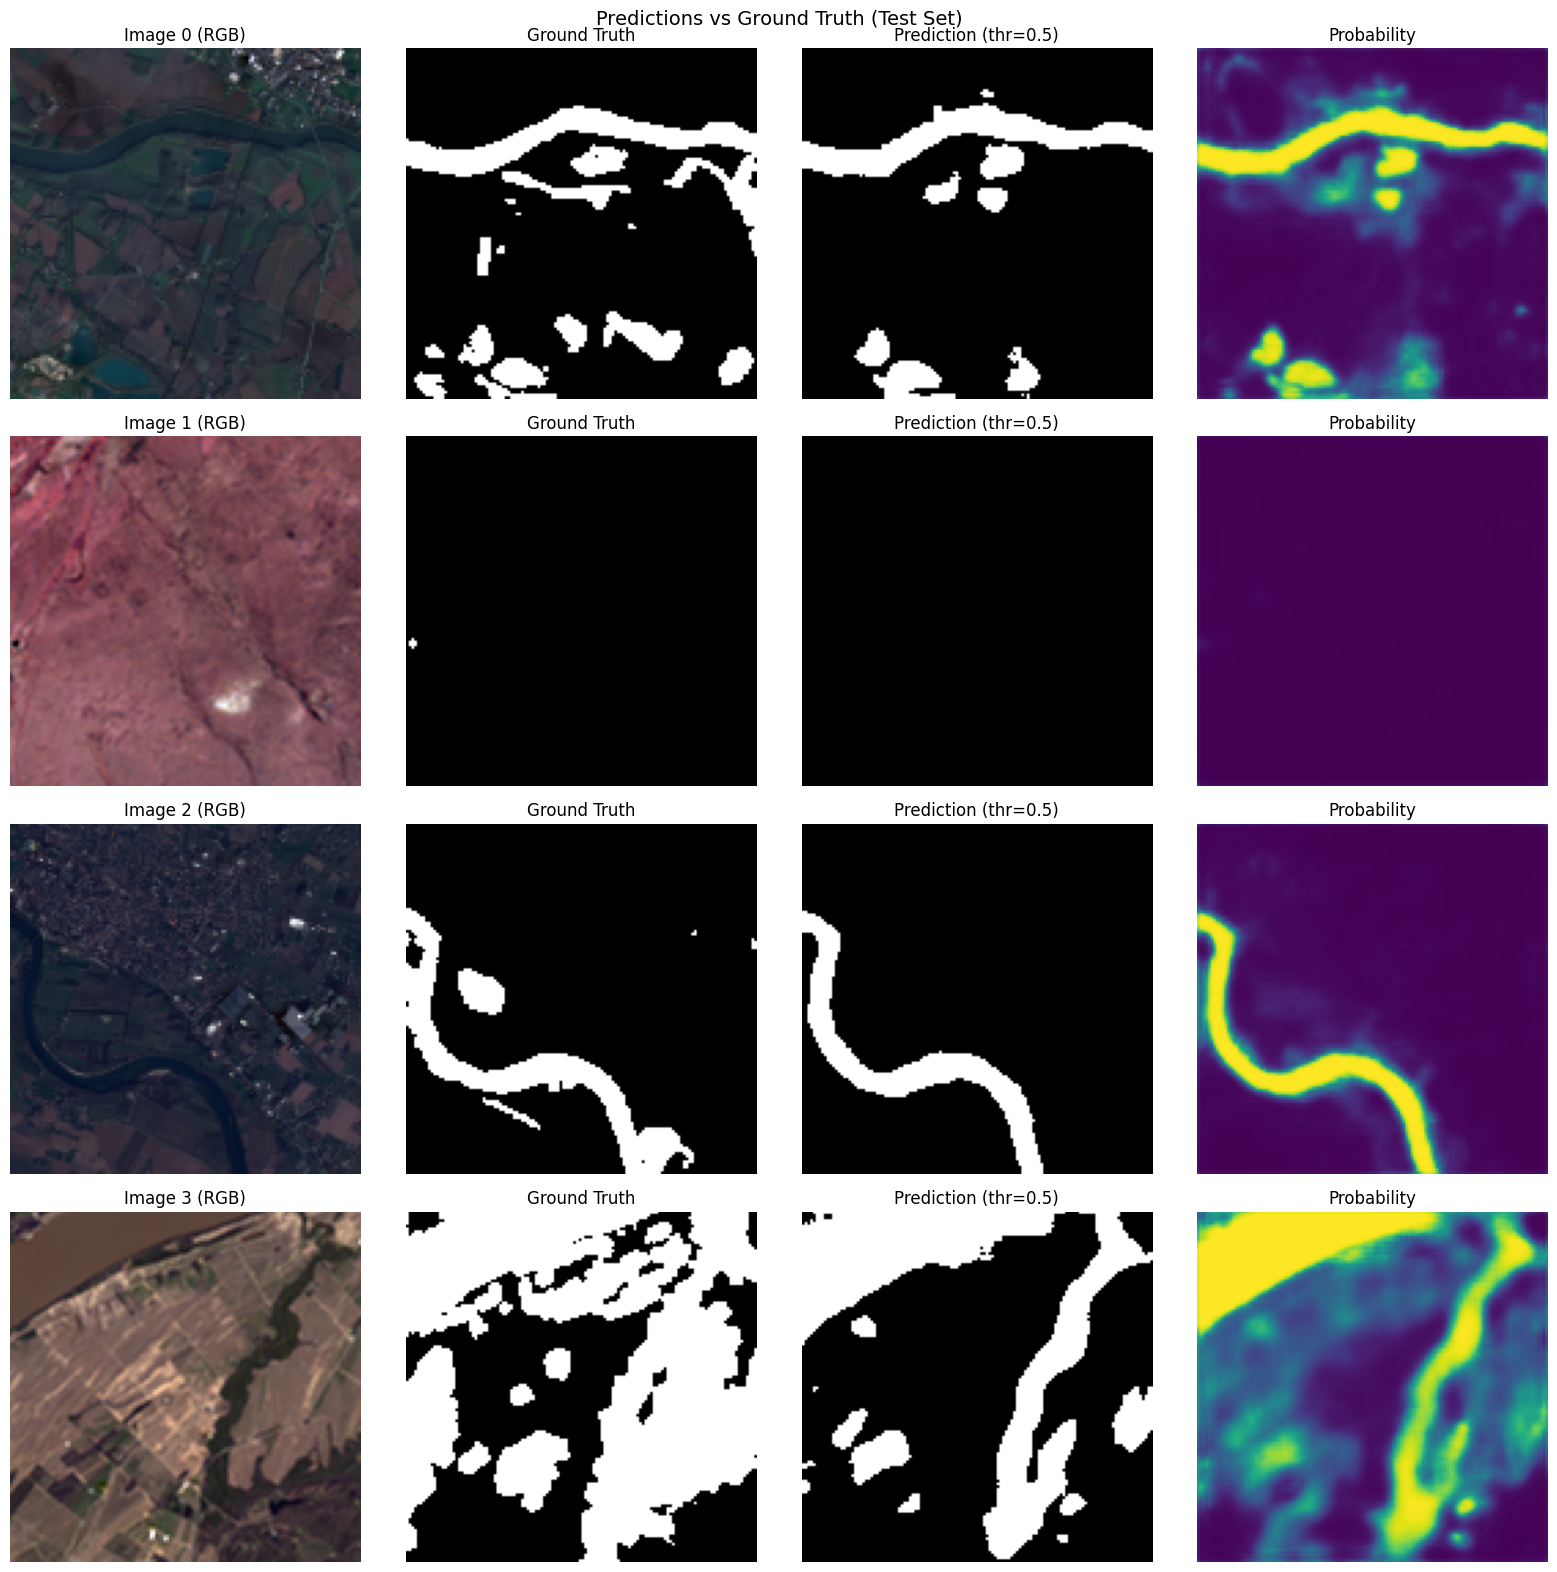

In [18]:
# ==============================================================================
# Section 10: Prediction Visualization
# ==============================================================================
@torch.no_grad()
def predict_batch(model, loader, n=3):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(DEVICE), y.to(DEVICE)
    logits = model(x)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    return x.cpu(), y.cpu(), preds.cpu(), probs.cpu()

x_vis, y_vis, p_vis, prob_vis = predict_batch(model, test_loader, n=4)

n_show = min(4, x_vis.size(0))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))
if n_show == 1:
    axes = axes[None, :]

for i in range(n_show):
    # RGB composite (Red=ch3, Green=ch2, Blue=ch1) using min-max per band
    rgb = x_vis[i, [3, 2, 1]].numpy()
    rgb = np.stack([(b - b.min()) / (b.max() - b.min() + 1e-8) for b in rgb], axis=-1)

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Image {i} (RGB)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_vis[i, 0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(p_vis[i, 0], cmap="gray")
    axes[i, 2].set_title("Prediction (thr=0.5)")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(prob_vis[i, 0], cmap="viridis", vmin=0, vmax=1)
    axes[i, 3].set_title("Probability")
    axes[i, 3].axis("off")

plt.suptitle("Predictions vs Ground Truth (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()